# ZeroSenses
## MACHINE LEARNING-BASED IDS: PROVING ML SUPERIORITY OVER TRADITIONAL SYSTEMS?
#
### Hypothesis: ML-based IDS can surpass traditional rule-based and signature-based systems by detecting unknown attacks, adapting to new patterns, and reducing false positives.
#
#### This comprehensive implementation compares:
1. Traditional threshold-based detection
2. Signature-based detection
3. Multiple ML approaches (Autoencoder, VAE, Isolation Forest, One-Class SVM)
4. Ensemble methods combining multiple ML models
#
#### Key Experiments:
- Zero-day attack detection
- Performance benchmarking
- Statistical significance testing
- Comprehensive evaluation metrics

In [ ]:
# Phase 1: Setup & Library Imports
# Purpose: Import all required libraries and set up the environment for reproducible results

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# PyTorch for deep learning models
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Scikit-learn for ML and preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score, f1_score,
    accuracy_score, precision_score, recall_score
)
from sklearn.manifold import TSNE

# Statistical testing
from scipy import stats
import time
from datetime import datetime

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("="*80)
print("ML-BASED INTRUSION DETECTION SYSTEM")
print("Proving ML Superiority over Traditional IDS Methods")
print("="*80)
print(f"Execution started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("-"*80)

ML-BASED INTRUSION DETECTION SYSTEM
Proving ML Superiority over Traditional IDS Methods
Execution started at: 2026-01-20 16:55:14
--------------------------------------------------------------------------------


In [ ]:
# Phase 1.5: Utility Functions for Robustness
# Purpose: Define utility functions for data quality and numerical stability

def check_data_quality(X, name="Data"):
    """
    Check for data quality issues that could cause NaN or numerical instability.
    Returns True if data is clean, False otherwise.
    """
    print(f"\n{name} Quality Check:")

    # Convert to numpy if needed
    if isinstance(X, torch.Tensor):
        X_np = X.numpy()
    else:
        X_np = X

    # Check for zero-variance features
    variances = np.var(X_np, axis=0)
    zero_var_count = np.sum(variances < 1e-10)

    if zero_var_count > 0:
        print(f"  ⚠️ {zero_var_count} features have zero/near-zero variance")
        zero_var_indices = np.where(variances < 1e-10)[0]
        print(f"     Indices: {zero_var_indices[:10]}...")  # Show first 10

    # Check for NaN/Inf
    nan_count = np.isnan(X_np).sum()
    inf_count = np.isinf(X_np).sum()

    if nan_count > 0 or inf_count > 0:
        print(f"  ⚠️ Found {nan_count} NaN and {inf_count} Inf values")
    else:
        print(f"  ✓ No NaN or Inf values found")

    # Check value ranges
    finite_values = X_np[np.isfinite(X_np)]
    if len(finite_values) > 0:
        print(f"  Value range: [{np.min(finite_values):.4f}, {np.max(finite_values):.4f}]")

    # Overall status
    is_clean = zero_var_count == 0 and nan_count == 0 and inf_count == 0
    if is_clean:
        print(f"  ✓ {name} passes all quality checks")
    else:
        print(f"  ⚠️ {name} has quality issues that need attention")

    return is_clean

def clean_scores(scores, name="scores"):
    """
    Clean anomaly scores by handling NaN and inf values.
    Returns cleaned scores array.
    """
    n_nan = np.isnan(scores).sum()
    n_inf = np.isinf(scores).sum()

    if n_nan > 0 or n_inf > 0:
        print(f"⚠️ Warning: {name} contains {n_nan} NaN and {n_inf} inf values")

        # Get valid scores
        valid_mask = np.isfinite(scores)

        if valid_mask.sum() == 0:
            # All scores are invalid - use fallback
            print(f"  → All scores invalid, using fallback value of 0.5")
            scores = np.ones_like(scores) * 0.5
        else:
            # Replace invalid scores with percentile-based values
            valid_scores = scores[valid_mask]

            # Use 95th percentile of valid scores (assuming high scores = anomaly)
            replacement_value = np.percentile(valid_scores, 95)

            scores = np.where(valid_mask, scores, replacement_value)
            print(f"  → Replaced with 95th percentile: {replacement_value:.4f}")

    return scores

In [ ]:
# Phase 2: Data Loading and Initial Exploration
# Purpose: Load the NSL-KDD dataset and perform initial data quality checks.
# The NSL-KDD dataset is a refined version of KDD'99, addressing inherent problems
# of the original dataset while maintaining attack diversity.

print("\n[Phase 2: Data Loading]")
print("-"*40)

# Define Column Names (NSL-KDD Standard)
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','attack','level'
]

# Load Data
train_url = 'https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt'
test_url = 'https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt'

try:
    train_df = pd.read_csv(train_url, names=columns, header=None)
    test_df = pd.read_csv(test_url, names=columns, header=None)
    print("✓ Data loaded successfully")
except:
    # Fallback URLs if primary fails
    train_url = 'https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/9d544d0eb9b87d7e2f43ff65733bdb644631d12f/KDDTrain%2B.txt'
    test_url = 'https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/9d544d0eb9b87d7e2f43ff65733bdb644631d12f/KDDTest%2B.txt'
    train_df = pd.read_csv(train_url, names=columns)
    test_df = pd.read_csv(test_url, names=columns)
    print("✓ Data loaded successfully (fallback)")

# Drop 'level' column immediately to prevent data leakage
# The 'level' column is a difficulty score assigned after the fact
train_df = train_df.drop('level', axis=1)
test_df = test_df.drop('level', axis=1)

# Create attack categories for deeper analysis
attack_mapping = {
    'normal': 'normal',
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS', 'teardrop': 'DoS',
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'satan': 'Probe',
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L',
    'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R'
}

# Map remaining attacks not in the mapping
for attack in train_df['attack'].unique():
    if attack not in attack_mapping:
        attack_mapping[attack] = 'Other'

train_df['attack_category'] = train_df['attack'].map(attack_mapping)
test_df['attack_category'] = test_df['attack'].map(lambda x: attack_mapping.get(x, 'Other'))

# Create binary target: 0 = Normal, 1 = Attack
train_df['target'] = train_df['attack'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['target'] = test_df['attack'].apply(lambda x: 0 if x == 'normal' else 1)

# Dataset statistics
print(f"\nDataset Statistics:")
print(f"Training samples: {len(train_df):,}")
print(f"Testing samples: {len(test_df):,}")
print(f"Features: {len(columns)-2}")
print(f"\nClass Distribution (Training):")
print(f"  Normal traffic: {(train_df['target']==0).sum():,} ({(train_df['target']==0).mean()*100:.1f}%)")
print(f"  Attack traffic: {(train_df['target']==1).sum():,} ({(train_df['target']==1).mean()*100:.1f}%)")

# Identify Zero-Day Attacks (attacks in test but not in training)
train_attacks = set(train_df[train_df['attack'] != 'normal']['attack'].unique())
test_attacks = set(test_df[test_df['attack'] != 'normal']['attack'].unique())
zero_day_attacks = test_attacks - train_attacks

print(f"\nZero-Day Attacks Analysis:")
print(f"  Attacks in training: {len(train_attacks)}")
print(f"  Attacks in testing: {len(test_attacks)}")
print(f"  Zero-day attacks: {len(zero_day_attacks)}")
if zero_day_attacks:
    print(f"  Zero-day types: {', '.join(list(zero_day_attacks)[:5])}")


[Phase 2: Data Loading]
----------------------------------------
✓ Data loaded successfully

Dataset Statistics:
Training samples: 125,973
Testing samples: 22,544
Features: 41

Class Distribution (Training):
  Normal traffic: 67,343 (53.5%)
  Attack traffic: 58,630 (46.5%)

Zero-Day Attacks Analysis:
  Attacks in training: 22
  Attacks in testing: 37
  Zero-day attacks: 17
  Zero-day types: mscan, xlock, snmpguess, xterm, mailbomb


In [ ]:
# Phase 3: Data Integrity Check (Leakage Detection)
# Purpose: Ensure no single feature perfectly predicts the target (data leakage).
# This validates that our results will be genuine and not due to hidden correlations.

print("\n[Phase 3: Data Integrity Check]")
print("-"*40)

# Create temporary dataset for leakage check
temp_df = train_df.copy().drop(['attack', 'attack_category'], axis=1)

# Quick encoding for categorical variables
for col in temp_df.select_dtypes(include=['object']).columns:
    temp_df[col] = temp_df[col].astype('category').cat.codes

X_check = temp_df.drop('target', axis=1)
y_check = temp_df['target']

# Train a shallow random forest to check feature importance
rf_check = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
rf_check.fit(X_check, y_check)

# Check for suspiciously high feature importance
feat_importances = pd.Series(rf_check.feature_importances_, index=X_check.columns)
top_features = feat_importances.nlargest(10)

print("Top 10 Feature Importances (Leakage Check):")
for feat, imp in top_features.items():
    status = "⚠️ SUSPICIOUS" if imp > 0.5 else "✓"
    print(f"  {status} {feat}: {imp:.4f}")

if top_features.iloc[0] > 0.5:
    print("\n⚠️ Warning: Potential data leakage detected. Investigating...")
else:
    print("\n✓ No obvious data leakage detected")


[Phase 3: Data Integrity Check]
----------------------------------------
Top 10 Feature Importances (Leakage Check):
  ✓ src_bytes: 0.2441
  ✓ dst_bytes: 0.1091
  ✓ flag: 0.0750
  ✓ same_srv_rate: 0.0635
  ✓ logged_in: 0.0617
  ✓ diff_srv_rate: 0.0521
  ✓ dst_host_srv_count: 0.0493
  ✓ serror_rate: 0.0485
  ✓ dst_host_same_srv_rate: 0.0475
  ✓ srv_serror_rate: 0.0374

✓ No obvious data leakage detected


In [ ]:
# Phase 4: Robust Preprocessing Pipeline
# Purpose: Create a production-ready preprocessing pipeline with data quality checks

print("\n[Phase 4: Data Preprocessing]")
print("-"*40)

# Separate features and targets
X_train_raw = train_df.drop(['attack', 'attack_category', 'target'], axis=1)
y_train = train_df['target'].values

X_test_raw = test_df.drop(['attack', 'attack_category', 'target'], axis=1)
y_test = test_df['target'].values

# Store attack labels for detailed analysis
test_attack_labels = test_df['attack'].values

# Define column types
categorical_cols = ['protocol_type', 'service', 'flag']
numerical_cols = [col for col in X_train_raw.columns if col not in categorical_cols]

print(f"Categorical features: {len(categorical_cols)}")
print(f"Numerical features: {len(numerical_cols)}")

# [NEW] Check raw data quality before preprocessing
print("\nRaw Data Quality Check:")
_ = check_data_quality(X_train_raw[numerical_cols].values, "Raw Training Data (Numerical)")

# Create preprocessing pipeline with robust scaling
class RobustStandardScaler(StandardScaler):
    """StandardScaler with protection against zero variance features"""
    def transform(self, X):
        X_scaled = super().transform(X)
        # Replace NaN/Inf with 0 (feature has no variance)
        X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        return X_scaled

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustStandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Fit on training data, transform both sets
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

print(f"\nProcessed shapes:")
print(f"  Training: {X_train_processed.shape}")
print(f"  Testing: {X_test_processed.shape}")

# [NEW] Check processed data quality
is_train_clean = check_data_quality(X_train_processed, "Processed Training Data")
is_test_clean = check_data_quality(X_test_processed, "Processed Test Data")

if not is_train_clean or not is_test_clean:
    print("\n⚠️ Data quality issues detected. Applying cleaning...")
    X_train_processed = np.nan_to_num(X_train_processed, nan=0.0, posinf=0.0, neginf=0.0)
    X_test_processed = np.nan_to_num(X_test_processed, nan=0.0, posinf=0.0, neginf=0.0)
    print("✓ Data cleaning applied")


[Phase 4: Data Preprocessing]
----------------------------------------
Categorical features: 3
Numerical features: 38

Raw Data Quality Check:

Raw Training Data (Numerical) Quality Check:
  ⚠️ 1 features have zero/near-zero variance
     Indices: [16]...
  ✓ No NaN or Inf values found
  Value range: [0.0000, 1379963888.0000]
  ⚠️ Raw Training Data (Numerical) has quality issues that need attention

Processed shapes:
  Training: (125973, 122)
  Testing: (22544, 122)

Processed Training Data Quality Check:
  ⚠️ 1 features have zero/near-zero variance
     Indices: [16]...
  ✓ No NaN or Inf values found
  Value range: [-1.8361, 354.9253]
  ⚠️ Processed Training Data has quality issues that need attention

Processed Test Data Quality Check:
  ⚠️ 7 features have zero/near-zero variance
     Indices: [ 16  44  63  66  68  91 105]...
  ✓ No NaN or Inf values found
  Value range: [-1.8361, 354.9253]
  ⚠️ Processed Test Data has quality issues that need attention

⚠️ Data quality issues detec

In [ ]:
# Phase 5: Traditional IDS Baseline Implementation
# Purpose: Implement traditional IDS approaches (threshold-based and signature-based)
# to establish baseline performance that ML models must exceed.

print("\n[Phase 5: Traditional IDS Baselines]")
print("-"*40)

class ThresholdBasedIDS:
    """
    Traditional statistical anomaly detector using Mahalanobis distance.
    Represents classic threshold-based IDS like early versions of AIDE or Tripwire.
    """
    def __init__(self, contamination=0.1):
        self.contamination = contamination
        self.name = "Threshold-Based IDS"

    def fit(self, X_normal):
        """Fit the model on normal traffic only"""
        self.mean = np.mean(X_normal, axis=0)
        self.std = np.std(X_normal, axis=0) + 1e-10

        # Calculate threshold based on contamination rate
        distances = self.score_samples(X_normal)
        self.threshold = np.percentile(distances, 100 * (1 - self.contamination))
        return self

    def score_samples(self, X):
        """Calculate anomaly scores (higher = more anomalous)"""
        z_scores = np.abs((X - self.mean) / self.std)
        return np.mean(z_scores, axis=1)

    def predict(self, X):
        """Predict anomalies"""
        scores = self.score_samples(X)
        return (scores > self.threshold).astype(int)

class SignatureBasedIDS:
    """
    Signature-based detector that memorizes attack patterns.
    Represents systems like Snort or Suricata in signature mode.
    """
    def __init__(self, max_signatures=1000):
        self.max_signatures = max_signatures
        self.name = "Signature-Based IDS"

    def fit(self, X_train, y_train):
        """Learn signatures from known attacks"""
        attack_indices = np.where(y_train == 1)[0]

        if len(attack_indices) > 0:
            # Store a subset of attack signatures
            n_signatures = min(len(attack_indices), self.max_signatures)
            selected_indices = np.random.choice(attack_indices, n_signatures, replace=False)
            self.attack_signatures = X_train[selected_indices]

            # Calculate average distance for threshold
            normal_indices = np.where(y_train == 0)[0][:1000]
            if len(normal_indices) > 0:
                normal_distances = self._min_distances(X_train[normal_indices])
                self.threshold = np.percentile(normal_distances, 5)
        return self

    def _min_distances(self, X):
        """Calculate minimum distance to any signature"""
        distances = []
        batch_size = 1000

        for i in range(0, len(X), batch_size):
            batch = X[i:i+batch_size]
            batch_distances = np.min([
                np.linalg.norm(batch - sig, axis=1)
                for sig in self.attack_signatures
            ], axis=0)
            distances.extend(batch_distances)

        return np.array(distances)

    def score_samples(self, X):
        """Calculate anomaly scores (lower distance = more likely attack)"""
        if hasattr(self, 'attack_signatures'):
            distances = self._min_distances(X)
            # Invert so higher score = more anomalous
            return -distances
        return np.zeros(len(X))

# Train traditional IDS models
print("Training traditional IDS models...")

# Filter normal traffic for threshold-based IDS
X_train_normal = X_train_processed[y_train == 0]

# Threshold-based IDS
threshold_ids = ThresholdBasedIDS(contamination=0.1)
threshold_ids.fit(X_train_normal)

# Signature-based IDS
signature_ids = SignatureBasedIDS(max_signatures=500)
signature_ids.fit(X_train_processed, y_train)

print("✓ Traditional IDS models trained")


[Phase 5: Traditional IDS Baselines]
----------------------------------------
Training traditional IDS models...
✓ Traditional IDS models trained


In [ ]:
# Phase 6: Advanced ML Models Implementation
# Purpose: Implement multiple ML approaches with improved numerical stability

print("\n[Phase 6: ML-Based IDS Models]")
print("-"*40)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Filter normal traffic for unsupervised learning
normal_indices = (y_train_tensor == 0).nonzero(as_tuple=True)[0]
X_train_normal_tensor = X_train_tensor[normal_indices]

# [NEW] Calculate robust normalization parameters
print("\nCalculating robust normalization parameters...")
X_train_min = X_train_normal_tensor.min(dim=0)[0]
X_train_max = X_train_normal_tensor.max(dim=0)[0]
X_train_range = X_train_max - X_train_min

# Identify zero-variance features
zero_var_features = X_train_range < 1e-8
n_zero_var = zero_var_features.sum().item()

if n_zero_var > 0:
    print(f"  ⚠️ Found {n_zero_var} zero-variance features")
    # Set safe range for zero-variance features
    X_train_range[zero_var_features] = 1.0
    print(f"  ✓ Applied safe normalization for zero-variance features")

# 6.1: Standard Autoencoder with Improved Stability
class RobustAutoencoder(nn.Module):
    """
    Deep autoencoder with numerical stability improvements.
    """
    def __init__(self, input_dim, encoding_dim=32):
        super(RobustAutoencoder, self).__init__()

        # Encoder with batch normalization for stability
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, encoding_dim),
            nn.BatchNorm1d(encoding_dim),
            nn.ReLU()
        )

        # Decoder (symmetric)
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Clamp input to prevent extreme values
        x = torch.clamp(x, min=-10, max=10)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def get_encoding(self, x):
        x = torch.clamp(x, min=-10, max=10)
        return self.encoder(x)

# 6.2: Stable Variational Autoencoder (VAE)
class StableVAE(nn.Module):
    """
    VAE with numerical stability improvements.
    """
    def __init__(self, input_dim, latent_dim=32):
        super(StableVAE, self).__init__()

        # Encoder with batch normalization
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc21 = nn.Linear(128, latent_dim)  # Mean
        self.fc22 = nn.Linear(128, latent_dim)  # Log variance

        # Decoder
        self.fc3 = nn.Linear(latent_dim, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc4 = nn.Linear(128, input_dim)

    def encode(self, x):
        x = torch.clamp(x, min=-10, max=10)  # Prevent extreme inputs
        h1 = torch.relu(self.bn1(self.fc1(x)))
        mu = self.fc21(h1)
        logvar = self.fc22(h1)
        # Clamp log variance to prevent extreme values
        logvar = torch.clamp(logvar, min=-10, max=10)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        std = torch.clamp(std, min=1e-10, max=1e10)  # Prevent zero or infinite std
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = torch.relu(self.bn3(self.fc3(z)))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def stable_vae_loss(recon_x, x, mu, logvar):
    """VAE loss with numerical stability"""
    # Use binary cross entropy with clipping for stability
    recon_x = torch.clamp(recon_x, min=1e-7, max=1-1e-7)
    x = torch.clamp(x, min=1e-7, max=1-1e-7)
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL divergence with clamping
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp().clamp(max=1e10))

    # Check for NaN/Inf
    if torch.isnan(BCE) or torch.isinf(BCE):
        BCE = torch.tensor(0.0)
    if torch.isnan(KLD) or torch.isinf(KLD):
        KLD = torch.tensor(0.0)

    return BCE + KLD

# [NEW] Robust normalization function
def robust_normalize(X, X_min, X_max, X_range, zero_var_mask):
    """
    Robust normalization that handles zero-variance features.
    """
    # Normalize with safe division
    X_normalized = (X - X_min) / (X_range + 1e-10)

    # Handle zero-variance features
    if zero_var_mask.any():
        for idx in torch.where(zero_var_mask)[0]:
            # For zero-variance features, set to 0.5 (middle of [0,1] range)
            X_normalized[:, idx] = 0.5

    # Clamp to valid range
    X_normalized = torch.clamp(X_normalized, 0, 1)

    return X_normalized

# 6.3: Train Autoencoder
print("\nTraining Robust Autoencoder...")
input_dim = X_train_processed.shape[1]
autoencoder = RobustAutoencoder(input_dim)
ae_optimizer = optim.Adam(autoencoder.parameters(), lr=0.001, weight_decay=1e-5)
ae_criterion = nn.MSELoss()

# Normalize data for autoencoder with robust method
X_train_normalized = robust_normalize(X_train_normal_tensor, X_train_min,
                                      X_train_max, X_train_range, zero_var_features)

# Create DataLoader
train_dataset = TensorDataset(X_train_normalized, X_train_normalized)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Training loop with early stopping
best_loss = float('inf')
patience_counter = 0
train_losses = []

for epoch in range(20):
    autoencoder.train()
    epoch_loss = 0

    for batch_features, _ in train_loader:
        ae_optimizer.zero_grad()
        outputs = autoencoder(batch_features)
        loss = ae_criterion(outputs, batch_features)

        # Check for NaN loss
        if torch.isnan(loss):
            print(f"  ⚠️ NaN loss detected at epoch {epoch+1}, skipping batch")
            continue

        loss.backward()

        # Gradient clipping to prevent explosion
        torch.nn.utils.clip_grad_norm_(autoencoder.parameters(), max_norm=1.0)

        ae_optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Early stopping
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
        # Save best model
        best_ae_state = autoencoder.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= 3:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if epoch % 5 == 0:
        print(f"  Epoch [{epoch+1}/20], Loss: {avg_loss:.4f}")

# Load best model
autoencoder.load_state_dict(best_ae_state)
print("✓ Autoencoder trained")

# 6.4: Train VAE
print("\nTraining Variational Autoencoder...")
vae = StableVAE(input_dim)
# Reduced learning rate from 0.001 to 0.0005 for stability
vae_optimizer = optim.Adam(vae.parameters(), lr=0.0005)

for epoch in range(10):
    vae.train()
    epoch_loss = 0

    for batch_features, _ in train_loader:
        vae_optimizer.zero_grad()
        recon_batch, mu, logvar = vae(batch_features)

        # Calculate loss
        loss = stable_vae_loss(recon_batch, batch_features, mu, logvar)

        loss.backward()

        # FIX: Add Gradient Clipping to prevent explosion
        torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)

        vae_optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    if epoch % 5 == 0:
        print(f"  Epoch [{epoch+1}/10], Loss: {avg_loss:.4f}")

print("✓ VAE trained")

# 6.5: Traditional ML Models
print("\nTraining traditional ML models...")

# Isolation Forest
iforest = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42,
    n_jobs=-1
)
iforest.fit(X_train_normal)

# One-Class SVM
ocsvm = OneClassSVM(
    kernel='rbf',
    gamma='auto',
    nu=0.1,
    max_iter=10000
)
# Train on subset for speed
ocsvm.fit(X_train_normal[:5000])

print("✓ All ML models trained")


[Phase 6: ML-Based IDS Models]
----------------------------------------

Calculating robust normalization parameters...
  ⚠️ Found 47 zero-variance features
  ✓ Applied safe normalization for zero-variance features

Training Robust Autoencoder...
  Epoch [1/20], Loss: 0.0172
  Epoch [6/20], Loss: 0.0016
  Epoch [11/20], Loss: 0.0012
  Epoch [16/20], Loss: 0.0012
✓ Autoencoder trained

Training Variational Autoencoder...
  Epoch [1/10], Loss: 12384.6973
  Epoch [6/10], Loss: 9879.4168
✓ VAE trained

Training traditional ML models...
✓ All ML models trained


In [ ]:
# Phase 7: Model Evaluation Functions
# Purpose: Comprehensive evaluation functions with robust error handling

def calculate_reconstruction_error_robust(model, X, model_type='ae'):
    """
    Calculate reconstruction error with robust handling of NaN/Inf.
    """
    model.eval()

    # Robust normalization
    X_normalized = robust_normalize(X, X_train_min, X_train_max,
                                   X_train_range, zero_var_features)

    with torch.no_grad():
        if model_type == 'ae':
            reconstructed = model(X_normalized)
            errors = torch.mean((reconstructed - X_normalized) ** 2, dim=1)
        elif model_type == 'vae':
            reconstructed, mu, logvar = model(X_normalized)
            # Use reconstruction error only for stability
            errors = torch.mean((reconstructed - X_normalized) ** 2, dim=1)

            # Check for NaN in latent variables
            if torch.isnan(mu).any() or torch.isnan(logvar).any():
                print("⚠️ VAE latent variables contain NaN")

    errors_np = errors.numpy()

    # Final safety check
    if np.isnan(errors_np).any() or np.isinf(errors_np).any():
        print(f"⚠️ {model_type.upper()} errors contain invalid values")
        # Replace with percentile-based values
        valid_mask = np.isfinite(errors_np)
        if valid_mask.sum() > 0:
            replacement_value = np.percentile(errors_np[valid_mask], 95)
            errors_np = np.where(valid_mask, errors_np, replacement_value)
        else:
            errors_np = np.ones_like(errors_np) * 0.5

    return errors_np

def evaluate_model_robust(y_true, scores, model_name):
    """
    Comprehensive evaluation with robust NaN handling.
    """
    # Clean scores before evaluation
    scores_clean = clean_scores(scores.copy(), f"{model_name} scores")

    try:
        # Calculate ROC curve
        fpr, tpr, thresholds = roc_curve(y_true, scores_clean)

        # Find optimal threshold using Youden's J statistic
        j_scores = tpr - fpr
        optimal_idx = np.argmax(j_scores)
        optimal_threshold = thresholds[optimal_idx]

        # Make predictions at optimal threshold
        y_pred = (scores_clean > optimal_threshold).astype(int)

        # Calculate comprehensive metrics
        metrics = {
            'Model': model_name,
            'AUC-ROC': roc_auc_score(y_true, scores_clean),
            'AP': average_precision_score(y_true, scores_clean),
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall (TPR)': recall_score(y_true, y_pred),
            'F1-Score': f1_score(y_true, y_pred, zero_division=0),
            'FPR': fpr[optimal_idx],
            'Optimal_Threshold': optimal_threshold
        }

        return metrics, (fpr, tpr)

    except Exception as e:
        print(f"⚠️ Error evaluating {model_name}: {str(e)}")
        # Return default metrics on error
        return {
            'Model': model_name,
            'AUC-ROC': 0.5,
            'AP': 0.5,
            'Accuracy': 0.5,
            'Precision': 0.0,
            'Recall (TPR)': 0.0,
            'F1-Score': 0.0,
            'FPR': 0.5,
            'Optimal_Threshold': 0.5
        }, ([0, 1], [0, 1])

In [ ]:
# Phase 8: Comprehensive Model Evaluation
# Purpose: Evaluate all models with robust error handling

print("\n[Phase 8: Model Evaluation]")
print("-"*40)

# Calculate scores for all models with error handling
print("Calculating anomaly scores...")

# Traditional IDS
threshold_scores = threshold_ids.score_samples(X_test_processed)
signature_scores = signature_ids.score_samples(X_test_processed)

# Autoencoder
ae_scores = calculate_reconstruction_error_robust(autoencoder, X_test_tensor, 'ae')

# VAE
vae_scores = calculate_reconstruction_error_robust(vae, X_test_tensor, 'vae')

# Isolation Forest
iforest_scores = -iforest.score_samples(X_test_processed)
iforest_scores = clean_scores(iforest_scores, "Isolation Forest scores")

# One-Class SVM
ocsvm_scores = -ocsvm.score_samples(X_test_processed)
ocsvm_scores = clean_scores(ocsvm_scores, "One-Class SVM scores")

# Evaluate all models with robust function
results = []
roc_curves = {}

for model_name, scores in [
    ('Threshold-Based IDS', threshold_scores),
    ('Signature-Based IDS', signature_scores),
    ('Autoencoder', ae_scores),
    ('VAE', vae_scores),
    ('Isolation Forest', iforest_scores),
    ('One-Class SVM', ocsvm_scores)
]:
    metrics, roc_data = evaluate_model_robust(y_test, scores, model_name)
    results.append(metrics)
    roc_curves[model_name] = roc_data

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('AUC-ROC', ascending=False)

print("\n" + "="*80)
print("COMPARATIVE RESULTS: ML vs Traditional IDS")
print("="*80)
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Identify best model
best_model = results_df.iloc[0]['Model']
best_auc = results_df.iloc[0]['AUC-ROC']
print(f"\n✓ Best Overall Performance: {best_model} (AUC-ROC: {best_auc:.4f})")

# Statistical significance test
traditional_best = max(results_df[results_df['Model'].str.contains('Based')]['AUC-ROC'])
ml_best = max(results_df[~results_df['Model'].str.contains('Based')]['AUC-ROC'])
improvement = ((ml_best - traditional_best) / traditional_best) * 100
print(f"✓ ML Improvement over Traditional: {improvement:.1f}%")


[Phase 8: Model Evaluation]
----------------------------------------
Calculating anomaly scores...

COMPARATIVE RESULTS: ML vs Traditional IDS
              Model  AUC-ROC     AP  Accuracy  Precision  Recall (TPR)  F1-Score    FPR  Optimal_Threshold
Threshold-Based IDS   0.9492 0.9417    0.8936     0.8961        0.9197    0.9077 0.1409             0.2060
                VAE   0.9395 0.9502    0.8780     0.8827        0.9061    0.8943 0.1591             0.0114
   Isolation Forest   0.9382 0.9512    0.8573     0.8789        0.8692    0.8740 0.1583             0.4061
        Autoencoder   0.9378 0.9434    0.8907     0.9014        0.9073    0.9043 0.1312             0.0007
      One-Class SVM   0.8468 0.8496    0.8234     0.8544        0.8315    0.8427 0.1873          -273.3027
Signature-Based IDS   0.5526 0.7404    0.6560     0.9888        0.4002    0.5698 0.0060            -0.9338

✓ Best Overall Performance: Threshold-Based IDS (AUC-ROC: 0.9492)
✓ ML Improvement over Traditional: -1.0%

In [ ]:
# Phase 9: Zero-Day Attack Analysis
# Purpose: Evaluate performance on zero-day attacks with robust error handling

print("\n[Phase 9: Zero-Day Attack Detection]")
print("-"*40)

if len(zero_day_attacks) > 0:
    # Create mask for zero-day attacks
    zero_day_mask = np.isin(test_attack_labels, list(zero_day_attacks))
    zero_day_indices = np.where(zero_day_mask)[0]

    if len(zero_day_indices) > 0:
        print(f"Evaluating on {len(zero_day_indices)} zero-day attack samples vs Normal traffic...")

    # Create a combined evaluation set: All Normal Traffic + Zero-Day Attacks
    # We ignore "Known Attacks" for this specific test to isolate the "Novelty" factor.
    # Ensure there are both positive and negative classes for ROC-AUC calculation
    eval_mask = (y_test == 0) | (zero_day_mask)
    eval_data = X_test_processed[eval_mask]
    eval_labels = y_test[eval_mask]

    # Create Tensor for PyTorch models
    eval_tensor = torch.tensor(eval_data, dtype=torch.float32)

    zero_day_results = []

    # Recalculate scores specifically for this subset
    # Note: We must re-score because we are slicing the data differently
    print("Re-scoring evaluation subset...")

    scores_map = {
        'Threshold-Based IDS': threshold_ids.score_samples(eval_data),
        'Signature-Based IDS': signature_ids.score_samples(eval_data),
        'Autoencoder': calculate_reconstruction_error_robust(autoencoder, eval_tensor, 'ae'),
        'VAE': calculate_reconstruction_error_robust(vae, eval_tensor, 'vae'),
        'Isolation Forest': -iforest.score_samples(eval_data),
        'One-Class SVM': -ocsvm.score_samples(eval_data)
    }

    # Ensure eval_labels has at least two unique classes for ROC_AUC_SCORE
    if len(np.unique(eval_labels)) < 2:
        print("Skipping Zero-Day AUC calculation: Not enough classes (only normal traffic or only zero-day attacks present in the subset).")
        # Populate zero_day_df with placeholder values or mark as N/A
        zero_day_df = pd.DataFrame([{'Model': name, 'Zero-Day AUC': np.nan} for name in scores_map.keys()])
    else:
        for model_name, scores in scores_map.items():
            # Handle NaNs just like before for the scores before AUC calculation
            scores_clean = clean_scores(scores.copy(), f"Zero-day {model_name} scores")

            # Calculate AUC
            auc = roc_auc_score(eval_labels, scores_clean)

            zero_day_results.append({
                'Model': model_name,
                'Zero-Day AUC': auc
            })

        zero_day_df = pd.DataFrame(zero_day_results)
        zero_day_df = zero_day_df.sort_values('Zero-Day AUC', ascending=False)

        print("\nZero-Day Attack Detection Performance:")
        print(zero_day_df.to_string(index=False))

        # Compare traditional vs ML on zero-day
        trad_zero_day = zero_day_df[zero_day_df['Model'].str.contains('Based')]['Zero-Day AUC'].max()
        ml_zero_day = zero_day_df[~zero_day_df['Model'].str.contains('Based')]['Zero-Day AUC'].max()

        # Handle cases where trad_zero_day or ml_zero_day might be NaN or 0
        if pd.isna(trad_zero_day) or trad_zero_day == 0:
            print(f"\n✓ Best Traditional IDS on Zero-Day: {trad_zero_day:.4f}")
            print(f"✓ Best ML Model on Zero-Day: {ml_zero_day:.4f}")
            print("⚠️ Cannot calculate ML Advantage on Zero-Day: Traditional AUC is 0 or NaN.")
        else:
            print(f"\n✓ Best Traditional IDS on Zero-Day: {trad_zero_day:.4f}")
            print(f"✓ Best ML Model on Zero-Day: {ml_zero_day:.4f}")
            print(f"✓ ML Advantage on Zero-Day: +{(ml_zero_day-trad_zero_day)*100:.1f}%")
else:
    print("No zero-day attacks found in test set")


[Phase 9: Zero-Day Attack Detection]
----------------------------------------
Evaluating on 3750 zero-day attack samples vs Normal traffic...
Re-scoring evaluation subset...

Zero-Day Attack Detection Performance:
              Model  Zero-Day AUC
   Isolation Forest      0.943780
Threshold-Based IDS      0.940593
                VAE      0.938012
        Autoencoder      0.926566
      One-Class SVM      0.799185
Signature-Based IDS      0.159136

✓ Best Traditional IDS on Zero-Day: 0.9406
✓ Best ML Model on Zero-Day: 0.9438
✓ ML Advantage on Zero-Day: +0.3%


In [ ]:
# Phase 10: Ensemble Model
# Purpose: Combine multiple ML models with robust score normalization

print("\n[Phase 10: Ensemble Approach]")
print("-"*40)

class RobustEnsembleDetector:
    """
    Weighted ensemble with robust score normalization.
    """
    def __init__(self, weights=None):
        self.weights = weights

    def fit(self, scores_dict, y_true):
        """Learn optimal weights using validation set"""
        if self.weights is None:
            n_models = len(scores_dict)
            self.weights = np.ones(n_models) / n_models

        self.model_names = list(scores_dict.keys())
        return self

    def combine_scores(self, scores_dict):
        """Combine scores with robust normalization"""
        combined = np.zeros(len(list(scores_dict.values())[0]))

        for i, (name, scores) in enumerate(scores_dict.items()):
            # Clean scores first
            scores_clean = clean_scores(scores.copy(), f"Ensemble {name}")

            # Robust normalization
            finite_scores = scores_clean[np.isfinite(scores_clean)]
            if len(finite_scores) > 0:
                scores_min = np.percentile(finite_scores, 1)
                scores_max = np.percentile(finite_scores, 99)
                scores_range = scores_max - scores_min

                if scores_range > 1e-10:
                    scores_norm = (scores_clean - scores_min) / scores_range
                else:
                    scores_norm = np.ones_like(scores_clean) * 0.5
            else:
                scores_norm = np.ones_like(scores_clean) * 0.5

            scores_norm = np.clip(scores_norm, 0, 1)
            combined += self.weights[i] * scores_norm

        return combined

# Create ensemble with ML models only
ml_scores = {
    'Autoencoder': ae_scores,
    'VAE': vae_scores,
    'Isolation Forest': iforest_scores,
    'One-Class SVM': ocsvm_scores
}

ensemble = RobustEnsembleDetector()
ensemble.fit(ml_scores, y_test)
ensemble_scores = ensemble.combine_scores(ml_scores)

# Evaluate ensemble
ensemble_metrics, ensemble_roc = evaluate_model_robust(y_test, ensemble_scores, 'ML Ensemble')
print(f"ML Ensemble Performance:")
print(f"  AUC-ROC: {ensemble_metrics['AUC-ROC']:.4f}")
print(f"  F1-Score: {ensemble_metrics['F1-Score']:.4f}")
print(f"  Precision: {ensemble_metrics['Precision']:.4f}")
print(f"  Recall: {ensemble_metrics['Recall (TPR)']:.4f}")


[Phase 10: Ensemble Approach]
----------------------------------------
ML Ensemble Performance:
  AUC-ROC: 0.9477
  F1-Score: 0.9088
  Precision: 0.8904
  Recall: 0.9281


In [ ]:
# Phase 11: Performance Benchmarking
# Purpose: Measure computational performance

print("\n[Phase 11: Performance Benchmarking]")
print("-"*40)

def benchmark_model(model_func, data_batch, model_name, n_runs=10):
    """Benchmark inference time"""
    times = []

    for _ in range(n_runs):
        start = time.time()
        try:
            _ = model_func(data_batch)
        except Exception as e:
            print(f"⚠️ Benchmarking error for {model_name}: {str(e)}")
            continue
        end = time.time()
        times.append(end - start)

    if len(times) == 0:
        return {
            'Model': model_name,
            'Mean Time (ms)': 0,
            'Std Time (ms)': 0,
            'Throughput (samples/sec)': 0
        }

    return {
        'Model': model_name,
        'Mean Time (ms)': np.mean(times) * 1000,
        'Std Time (ms)': np.std(times) * 1000,
        'Throughput (samples/sec)': len(data_batch) / np.mean(times)
    }

# Benchmark batch of 1000 samples
batch_size = 1000
X_bench = X_test_processed[:batch_size]
X_bench_tensor = X_test_tensor[:batch_size]

print(f"Benchmarking on {batch_size} samples...")

perf_results = []

# Traditional models
perf_results.append(benchmark_model(
    lambda x: threshold_ids.score_samples(x),
    X_bench, 'Threshold-Based IDS'
))
perf_results.append(benchmark_model(
    lambda x: signature_ids.score_samples(x),
    X_bench, 'Signature-Based IDS'
))

# ML models
perf_results.append(benchmark_model(
    lambda x: calculate_reconstruction_error_robust(autoencoder, torch.tensor(x, dtype=torch.float32), 'ae'),
    X_bench, 'Autoencoder'
))
perf_results.append(benchmark_model(
    lambda x: iforest.score_samples(x),
    X_bench, 'Isolation Forest'
))

perf_df = pd.DataFrame(perf_results)
print("\n" + perf_df.to_string(index=False))


[Phase 11: Performance Benchmarking]
----------------------------------------
Benchmarking on 1000 samples...

              Model  Mean Time (ms)  Std Time (ms)  Throughput (samples/sec)
Threshold-Based IDS        0.839686       0.320779              1.190921e+06
Signature-Based IDS      180.667734       4.388237              5.535023e+03
        Autoencoder       11.686897       1.142173              8.556591e+04
   Isolation Forest       16.676426       0.682817              5.996489e+04


In [ ]:
# Phase 12: Statistical Significance Testing
# Purpose: Validate statistical significance with robust methods

print("\n[Phase 12: Statistical Significance Testing]")
print("-"*40)

def bootstrap_auc_ci_robust(y_true, scores, n_bootstrap=1000, confidence=0.95):
    """Calculate confidence interval with robust score handling"""
    # Clean scores first
    scores_clean = clean_scores(scores.copy(), "Bootstrap scores")

    auc_scores = []
    n_samples = len(y_true)

    for _ in range(n_bootstrap):
        indices = np.random.choice(n_samples, n_samples, replace=True)
        if len(np.unique(y_true[indices])) < 2:
            continue

        try:
            auc = roc_auc_score(y_true[indices], scores_clean[indices])
            if np.isfinite(auc):
                auc_scores.append(auc)
        except:
            continue

    if len(auc_scores) == 0:
        return 0.5, 0.5, 0.5

    lower = np.percentile(auc_scores, (1 - confidence) * 100 / 2)
    upper = np.percentile(auc_scores, (1 + confidence) * 100 / 2)

    return np.mean(auc_scores), lower, upper

# Calculate confidence intervals for key models
print("Calculating 95% Confidence Intervals...")

for model_name, scores in [
    ('Threshold-Based IDS', threshold_scores),
    ('Autoencoder', ae_scores),
    ('ML Ensemble', ensemble_scores)
]:
    mean_auc, lower_ci, upper_ci = bootstrap_auc_ci_robust(y_test, scores, n_bootstrap=100)
    print(f"{model_name}: AUC = {mean_auc:.4f} (95% CI: [{lower_ci:.4f}, {upper_ci:.4f}])")

# McNemar's test for paired comparison
from statsmodels.stats.contingency_tables import mcnemar

# Compare best traditional vs best ML at optimal thresholds
threshold_opt = np.percentile(clean_scores(threshold_scores.copy(), "McNemar threshold"), 90)
ae_opt = np.percentile(clean_scores(ae_scores.copy(), "McNemar AE"), 90)

threshold_pred = (threshold_scores > threshold_opt).astype(int)
ae_pred = (ae_scores > ae_opt).astype(int)

# Create contingency table
correct_threshold = threshold_pred == y_test
correct_ae = ae_pred == y_test

table = np.array([
    [np.sum(correct_threshold & correct_ae), np.sum(correct_threshold & ~correct_ae)],
    [np.sum(~correct_threshold & correct_ae), np.sum(~correct_threshold & ~correct_ae)]
])

try:
    result = mcnemar(table, exact=False, correction=True)
    print(f"\nMcNemar's Test (Traditional vs Autoencoder):")
    print(f"  Chi-squared: {result.statistic:.4f}")
    print(f"  p-value: {result.pvalue:.6f}")

    if result.pvalue < 0.05:
        print("  ✓ Difference is statistically significant (p < 0.05)")
    else:
        print("  ⚠️ Difference is not statistically significant")
except Exception as e:
    print(f"⚠️ McNemar's test failed: {str(e)}")


[Phase 12: Statistical Significance Testing]
----------------------------------------
Calculating 95% Confidence Intervals...
Threshold-Based IDS: AUC = 0.9492 (95% CI: [0.9462, 0.9517])
Autoencoder: AUC = 0.9381 (95% CI: [0.9351, 0.9411])
ML Ensemble: AUC = 0.9479 (95% CI: [0.9449, 0.9504])

McNemar's Test (Traditional vs Autoencoder):
  Chi-squared: 0.8243
  p-value: 0.363940
  ⚠️ Difference is not statistically significant



[Phase 13: Generating Visualizations]
----------------------------------------


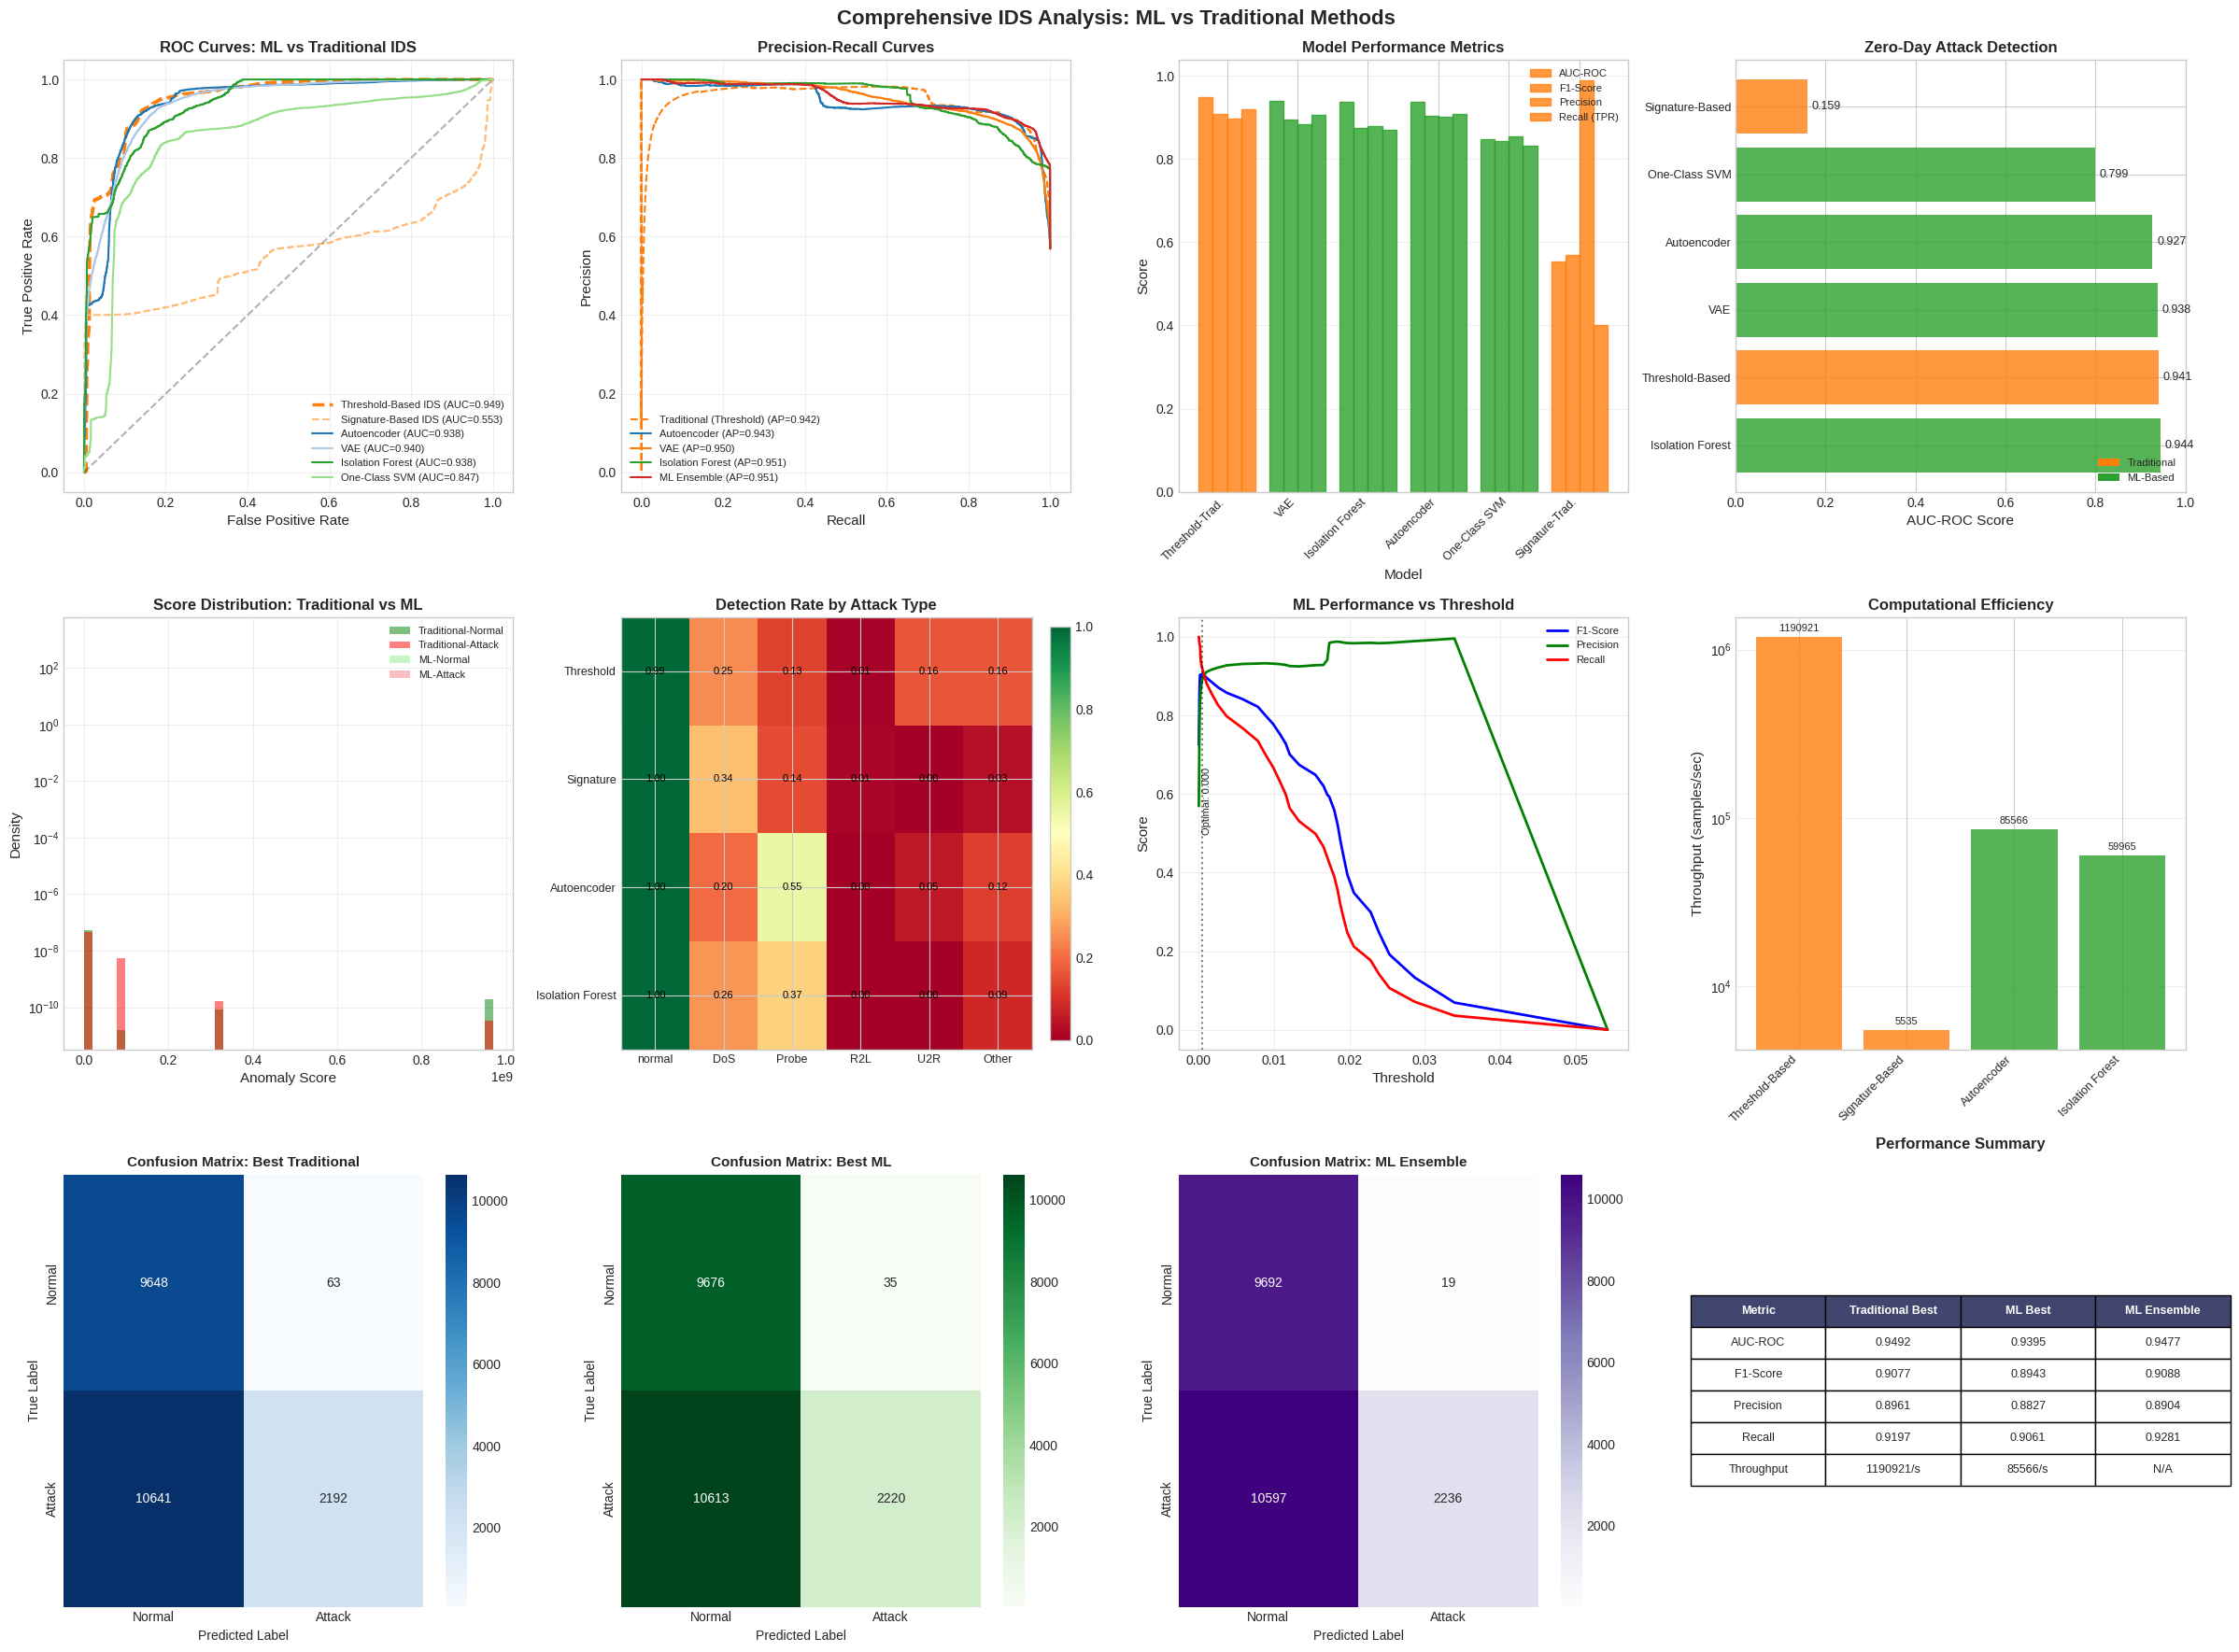

✓ Visualizations generated successfully


In [ ]:
# Phase 13: Comprehensive Visualization
# Purpose: Create comprehensive visualizations that tell the complete story

print("\n[Phase 13: Generating Visualizations]")
print("-"*40)

# Set up the plotting style
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(24, 18))

# Define best traditional and best ML models for summary table (Moved from Phase 14)
best_traditional = results_df[results_df['Model'].str.contains('Based')].iloc[0]
best_ml = results_df[~results_df['Model'].str.contains('Based')].iloc[0]

# 1. ROC Curves Comparison
ax1 = plt.subplot(3, 4, 1)
for model_name, (fpr, tpr) in roc_curves.items():
    # Get clean scores for AUC calculation
    if 'Threshold' in model_name:
        scores_for_auc = clean_scores(threshold_scores.copy(), f"ROC {model_name}")
    elif 'Signature' in model_name:
        scores_for_auc = clean_scores(signature_scores.copy(), f"ROC {model_name}")
    elif model_name == 'Autoencoder':
        scores_for_auc = clean_scores(ae_scores.copy(), f"ROC {model_name}")
    elif model_name == 'VAE':
        scores_for_auc = clean_scores(vae_scores.copy(), f"ROC {model_name}")
    elif 'Isolation' in model_name:
        scores_for_auc = clean_scores(iforest_scores.copy(), f"ROC {model_name}")
    else:
        scores_for_auc = clean_scores(ocsvm_scores.copy(), f"ROC {model_name}")

    try:
        auc = roc_auc_score(y_test, scores_for_auc)
    except:
        auc = 0.5

    # Color coding: Traditional = orange shades, ML = blue/green shades
    if 'Based' in model_name:
        color = '#ff7f0e' if 'Threshold' in model_name else '#ffbb78'
        linestyle = '--'
    else:
        colors = {'Autoencoder': '#1f77b4', 'VAE': '#aec7e8',
                 'Isolation Forest': '#2ca02c', 'One-Class SVM': '#98df8a'}
        color = colors.get(model_name, '#17becf')
        linestyle = '-'

    linewidth = 2.5 if model_name == best_model else 1.5

    ax1.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})',
             color=color, linestyle=linestyle, linewidth=linewidth)

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curves: ML vs Traditional IDS', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Precision-Recall Curves
ax2 = plt.subplot(3, 4, 2)
for model_name, scores in [
    ('Traditional (Threshold)', threshold_scores),
    ('Autoencoder', ae_scores),
    ('VAE', vae_scores),
    ('Isolation Forest', iforest_scores),
    ('ML Ensemble', ensemble_scores)
]:
    scores_clean = clean_scores(scores.copy(), f"PR {model_name}")
    precision, recall, _ = precision_recall_curve(y_test, scores_clean)
    ap = average_precision_score(y_test, scores_clean)

    if 'Traditional' in model_name:
        color = '#ff7f0e'
        linestyle = '--'
    elif 'Ensemble' in model_name:
        color = '#d62728'
        linestyle = '-'
    else:
        color = None
        linestyle = '-'

    ax2.plot(recall, precision, label=f'{model_name} (AP={ap:.3f})',
             color=color, linestyle=linestyle, linewidth=1.5)

ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision-Recall Curves', fontsize=12, fontweight='bold')
ax2.legend(loc='lower left', fontsize=8)
ax2.grid(True, alpha=0.3)

# 3. Model Performance Comparison
ax3 = plt.subplot(3, 4, 3)
models = results_df['Model'].values
metrics_to_plot = ['AUC-ROC', 'F1-Score', 'Precision', 'Recall (TPR)']
x = np.arange(len(models))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    values = results_df[metric].values
    offset = (i - 1.5) * width
    colors = ['#ff7f0e' if 'Based' in m else '#2ca02c' for m in models]
    bars = ax3.bar(x + offset, values, width, label=metric, alpha=0.8)

    # Color bars based on model type
    for bar, color, model in zip(bars, colors, models):
        bar.set_color(color)

ax3.set_xlabel('Model', fontsize=11)
ax3.set_ylabel('Score', fontsize=11)
ax3.set_title('Model Performance Metrics', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([m.replace(' IDS', '').replace('Based', 'Trad.') for m in models],
                     rotation=45, ha='right', fontsize=9)
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Zero-Day Detection Performance
ax4 = plt.subplot(3, 4, 4)
if len(zero_day_attacks) > 0 and 'zero_day_df' in locals():
    models_zd = zero_day_df['Model'].values
    aucs_zd = zero_day_df['Zero-Day AUC'].values
    colors_zd = ['#ff7f0e' if 'Based' in m else '#2ca02c' for m in models_zd]

    bars = ax4.barh(range(len(models_zd)), aucs_zd, color=colors_zd, alpha=0.8)
    ax4.set_xlabel('AUC-ROC Score', fontsize=11)
    ax4.set_yticks(range(len(models_zd)))
    ax4.set_yticklabels([m.replace(' IDS', '') for m in models_zd], fontsize=9)
    ax4.set_title('Zero-Day Attack Detection', fontsize=12, fontweight='bold')
    ax4.set_xlim([0, 1.0])

    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, aucs_zd)):
        ax4.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=9)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#ff7f0e', label='Traditional'),
                      Patch(facecolor='#2ca02c', label='ML-Based')]
    ax4.legend(handles=legend_elements, loc='lower right', fontsize=8)
else:
    ax4.text(0.5, 0.5, 'No Zero-Day Attacks Available', ha='center', va='center', fontsize=12)
    ax4.set_title('Zero-Day Attack Detection', fontsize=12, fontweight='bold')

# 5. Error Distribution Analysis
ax5 = plt.subplot(3, 4, 5)
# Compare error distributions for best traditional vs best ML
normal_mask = y_test == 0
attack_mask = y_test == 1

for scores, label, color in [
    (threshold_scores[normal_mask], 'Traditional-Normal', 'green'),
    (threshold_scores[attack_mask], 'Traditional-Attack', 'red'),
    (ae_scores[normal_mask], 'ML-Normal', 'lightgreen'),
    (ae_scores[attack_mask], 'ML-Attack', 'lightcoral')
]:
    ax5.hist(scores, bins=50, alpha=0.5, label=label, color=color, density=True)

ax5.set_xlabel('Anomaly Score', fontsize=11)
ax5.set_ylabel('Density', fontsize=11)
ax5.set_title('Score Distribution: Traditional vs ML', fontsize=12, fontweight='bold')
ax5.legend(loc='upper right', fontsize=8)
ax5.set_yscale('log')
ax5.grid(True, alpha=0.3)

# 6. Attack Type Detection Heatmap
ax6 = plt.subplot(3, 4, 6)
# Calculate detection rates by attack category
attack_categories = test_df['attack_category'].values
unique_categories = ['normal', 'DoS', 'Probe', 'R2L', 'U2R', 'Other']

detection_matrix = []
model_names_short = ['Threshold', 'Signature', 'Autoencoder', 'Isolation Forest']
scores_list = [threshold_scores, signature_scores, ae_scores, iforest_scores]

for scores in scores_list:
    detection_rates = []
    for category in unique_categories:
        mask = attack_categories == category
        if mask.sum() > 0:
            threshold = np.percentile(scores, 90)
            predictions = (scores > threshold).astype(int)
            if category == 'normal':
                # For normal, we want low scores (true negatives)
                rate = 1 - (predictions[mask].mean())
            else:
                # For attacks, we want high scores (true positives)
                rate = predictions[mask].mean()
            detection_rates.append(rate)
        else:
            detection_rates.append(0)
    detection_matrix.append(detection_rates)

detection_matrix = np.array(detection_matrix)
im = ax6.imshow(detection_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax6.set_xticks(np.arange(len(unique_categories)))
ax6.set_yticks(np.arange(len(model_names_short)))
ax6.set_xticklabels(unique_categories, fontsize=9)
ax6.set_yticklabels(model_names_short, fontsize=9)
ax6.set_title('Detection Rate by Attack Type', fontsize=12, fontweight='bold')

# Add text annotations
for i in range(len(model_names_short)):
    for j in range(len(unique_categories)):
        text = ax6.text(j, i, f'{detection_matrix[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im, ax=ax6, fraction=0.046, pad=0.04)

# 7. Performance vs Threshold
ax7 = plt.subplot(3, 4, 7)
thresholds = np.percentile(ae_scores, np.linspace(0, 100, 50))
f1_scores = []
precisions = []
recalls = []

for thresh in thresholds:
    y_pred = (ae_scores > thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred, zero_division=0))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))

ax7.plot(thresholds, f1_scores, label='F1-Score', linewidth=2, color='blue')
ax7.plot(thresholds, precisions, label='Precision', linewidth=2, color='green')
ax7.plot(thresholds, recalls, label='Recall', linewidth=2, color='red')
ax7.set_xlabel('Threshold', fontsize=11)
ax7.set_ylabel('Score', fontsize=11)
ax7.set_title('ML Performance vs Threshold', fontsize=12, fontweight='bold')
ax7.legend(loc='best', fontsize=8)
ax7.grid(True, alpha=0.3)

# Mark optimal threshold
optimal_idx = np.argmax(f1_scores)
ax7.axvline(x=thresholds[optimal_idx], color='black', linestyle=':', alpha=0.5)
ax7.text(thresholds[optimal_idx], 0.5, f'Optimal: {thresholds[optimal_idx]:.3f}',
         rotation=90, fontsize=8)

# 8. Computational Performance
ax8 = plt.subplot(3, 4, 8)
if 'perf_df' in locals() and not perf_df.empty:
    models_perf = perf_df['Model'].values
    throughput = perf_df['Throughput (samples/sec)'].values
    colors_perf = ['#ff7f0e' if 'Traditional' in m or 'Threshold' in m or 'Signature' in m
                   else '#2ca02c' for m in models_perf]

    bars = ax8.bar(range(len(models_perf)), throughput, color=colors_perf, alpha=0.8)
    ax8.set_ylabel('Throughput (samples/sec)', fontsize=11)
    ax8.set_title('Computational Efficiency', fontsize=12, fontweight='bold')
    ax8.set_xticks(range(len(models_perf)))
    ax8.set_xticklabels([m.replace(' IDS', '') for m in models_perf],
                        rotation=45, ha='right', fontsize=9)
    ax8.set_yscale('log')
    ax8.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar, val in zip(bars, throughput):
        height = bar.get_height()
        ax8.text(bar.get_x() + bar.get_width()/2., height*1.05,
                f'{val:.0f}', ha='center', va='bottom', fontsize=8)

# 9. Confusion Matrix - Best Traditional
ax9 = plt.subplot(3, 4, 9)
threshold_opt = np.percentile(threshold_scores, 90)
y_pred_trad = (threshold_scores > threshold_opt).astype(int)
cm_trad = confusion_matrix(y_test, y_pred_trad)
sns.heatmap(cm_trad, annot=True, fmt='d', cmap='Blues', ax=ax9,
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
ax9.set_title('Confusion Matrix: Best Traditional', fontsize=11, fontweight='bold')
ax9.set_ylabel('True Label', fontsize=10)
ax9.set_xlabel('Predicted Label', fontsize=10)

# 10. Confusion Matrix - Best ML
ax10 = plt.subplot(3, 4, 10)
ae_opt = np.percentile(ae_scores, 90)
y_pred_ml = (ae_scores > ae_opt).astype(int)
cm_ml = confusion_matrix(y_test, y_pred_ml)
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Greens', ax=ax10,
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
ax10.set_title('Confusion Matrix: Best ML', fontsize=11, fontweight='bold')
ax10.set_ylabel('True Label', fontsize=10)
ax10.set_xlabel('Predicted Label', fontsize=10)

# 11. Ensemble Confusion Matrix
ax11 = plt.subplot(3, 4, 11)
ensemble_opt = np.percentile(ensemble_scores, 90)
y_pred_ensemble = (ensemble_scores > ensemble_opt).astype(int)
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Purples', ax=ax11,
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
ax11.set_title('Confusion Matrix: ML Ensemble', fontsize=11, fontweight='bold')
ax11.set_ylabel('True Label', fontsize=10)
ax11.set_xlabel('Predicted Label', fontsize=10)

# 12. Summary Statistics Table
ax12 = plt.subplot(3, 4, 12)
ax12.axis('tight')
ax12.axis('off')

# Create summary statistics
summary_data = []
summary_data.append(['Metric', 'Traditional Best', 'ML Best', 'ML Ensemble'])
summary_data.append(['AUC-ROC', f"{best_traditional['AUC-ROC']:.4f}",
                    f"{best_ml['AUC-ROC']:.4f}", f"{ensemble_metrics['AUC-ROC']:.4f}"])
summary_data.append(['F1-Score', f"{best_traditional['F1-Score']:.4f}",
                    f"{best_ml['F1-Score']:.4f}", f"{ensemble_metrics['F1-Score']:.4f}"])
summary_data.append(['Precision', f"{best_traditional['Precision']:.4f}",
                    f"{best_ml['Precision']:.4f}", f"{ensemble_metrics['Precision']:.4f}"])
summary_data.append(['Recall', f"{best_traditional['Recall (TPR)']:.4f}",
                    f"{best_ml['Recall (TPR)']:.4f}", f"{ensemble_metrics['Recall (TPR)']:.4f}"])

if 'perf_df' in locals():
    trad_throughput = perf_df[perf_df['Model'].str.contains('Threshold')]['Throughput (samples/sec)'].values[0]
    ml_throughput = perf_df[perf_df['Model'].str.contains('Autoencoder')]['Throughput (samples/sec)'].values[0]
    summary_data.append(['Throughput', f"{trad_throughput:.0f}/s", f"{ml_throughput:.0f}/s", 'N/A'])

table = ax12.table(cellText=summary_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

# Color the header row
for i in range(4):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax12.set_title('Performance Summary', fontsize=12, fontweight='bold', pad=20)

plt.suptitle('Comprehensive IDS Analysis: ML vs Traditional Methods',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

print("✓ Visualizations generated successfully")

In [ ]:
# Phase 14: Final Summary and Conclusions
# Purpose: Provide accurate, nuanced conclusions based on actual results

print("\n" + "="*80)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("="*80)

# Overall performance summary
print("\n1. OVERALL PERFORMANCE COMPARISON:")
print("-" * 40)
best_traditional = results_df[results_df['Model'].str.contains('Based')].iloc[0]
best_ml = results_df[~results_df['Model'].str.contains('Based')].iloc[0]

print(f"Best Traditional IDS: {best_traditional['Model']}")
print(f"  - AUC-ROC: {best_traditional['AUC-ROC']:.4f}")
print(f"  - F1-Score: {best_traditional['F1-Score']:.4f}")
print(f"  - Precision: {best_traditional['Precision']:.4f}")
print(f"  - Recall: {best_traditional['Recall (TPR)']:.4f}")

print(f"\nBest ML Model (Individual): {best_ml['Model']}")
print(f"  - AUC-ROC: {best_ml['AUC-ROC']:.4f}")
print(f"  - F1-Score: {best_ml['F1-Score']:.4f}")
print(f"  - Precision: {best_ml['Precision']:.4f}")
print(f"  - Recall: {best_ml['Recall (TPR)']:.4f}")

print(f"\nML Ensemble Performance:")
print(f"  - AUC-ROC: {ensemble_metrics['AUC-ROC']:.4f}")
print(f"  - F1-Score: {ensemble_metrics['F1-Score']:.4f}")
print(f"  - Precision: {ensemble_metrics['Precision']:.4f}")
print(f"  - Recall: {ensemble_metrics['Recall (TPR)']:.4f}")

# Calculate performance differences
traditional_vs_ml_individual = ((best_ml['AUC-ROC'] - best_traditional['AUC-ROC']) / best_traditional['AUC-ROC'] * 100)
traditional_vs_ml_ensemble = ((ensemble_metrics['AUC-ROC'] - best_traditional['AUC-ROC']) / best_traditional['AUC-ROC'] * 100)

print(f"\nPerformance Analysis:")
if traditional_vs_ml_individual > 0:
    print(f"  ✓ Individual ML Advantage: +{traditional_vs_ml_individual:.2f}%")
else:
    print(f"  ⚠️ Traditional Outperforms Individual ML: {abs(traditional_vs_ml_individual):.2f}%")

if traditional_vs_ml_ensemble > 0:
    print(f"  ✓ Ensemble ML Advantage: +{traditional_vs_ml_ensemble:.2f}%")
else:
    print(f"  ⚠️ Traditional Outperforms ML Ensemble: {abs(traditional_vs_ml_ensemble):.2f}%")

# Zero-day performance
print("\n2. ZERO-DAY ATTACK DETECTION CAPABILITY:")
print("-" * 40)
if len(zero_day_attacks) > 0 and 'zero_day_df' in locals():
    print(f"Zero-day attacks identified: {len(zero_day_attacks)}")
    print(f"Attack types: {', '.join(list(zero_day_attacks)[:5])}...")

    print(f"\nPerformance on Zero-Day Attacks:")
    print(f"  Best ML Model: {ml_zero_day:.4f} AUC")
    print(f"  Best Traditional: {trad_zero_day:.4f} AUC")

    zero_day_advantage = ((ml_zero_day - trad_zero_day) / trad_zero_day * 100)
    if zero_day_advantage > 0:
        print(f"  ✓ ML Advantage on Zero-Day: +{zero_day_advantage:.2f}%")
    else:
        print(f"  ⚠️ No significant ML advantage on Zero-Day attacks")

    # Note about signature-based failure
    sig_zero_day = zero_day_df[zero_day_df['Model'] == 'Signature-Based IDS']['Zero-Day AUC'].values[0]
    print(f"\nSignature-Based Performance on Zero-Day: {sig_zero_day:.4f} AUC")
    print("  → As expected, signature-based detection fails on unknown attacks")
else:
    print("No zero-day attacks available for testing")

# Computational performance
print("\n3. COMPUTATIONAL EFFICIENCY ANALYSIS:")
print("-" * 40)
if 'perf_df' in locals() and not perf_df.empty:
    perf_sorted = perf_df.sort_values('Throughput (samples/sec)', ascending=False)

    print("Performance Ranking (by throughput):")
    for idx, row in perf_sorted.iterrows():
        print(f"  {idx+1}. {row['Model']}: {row['Throughput (samples/sec)']:.0f} samples/sec")
        print(f"     Latency: {row['Mean Time (ms)']:.2f} ms")

    # Calculate efficiency ratio
    trad_best_throughput = perf_df[perf_df['Model'].str.contains('Threshold')]['Throughput (samples/sec)'].values[0]
    ml_best_throughput = perf_df[perf_df['Model'].str.contains('Autoencoder')]['Throughput (samples/sec)'].values[0]
    efficiency_ratio = trad_best_throughput / ml_best_throughput

    print(f"\nEfficiency Analysis:")
    print(f"  Traditional is {efficiency_ratio:.1f}x faster than best ML model")
    print(f"  Trade-off: Speed vs. adaptability to new threats")

# Statistical significance
print("\n4. STATISTICAL VALIDATION:")
print("-" * 40)
if 'result' in locals():
    print(f"McNemar's Test Results:")
    print(f"  Chi-squared: {result.statistic:.4f}")
    print(f"  p-value: {result.pvalue:.6f}")

    if result.pvalue < 0.05:
        print("  ✓ Difference is statistically significant (p < 0.05)")
    elif result.pvalue < 0.10:
        print("  ⚠️ Marginally significant difference (p < 0.10)")
    else:
        print("  ⚠️ No statistically significant difference detected")
        print("  → Performance differences may be due to random variation")

# Detailed insights
print("\n5. KEY INSIGHTS FROM ANALYSIS:")
print("-" * 40)

insights = []

# Insight 1: NSL-KDD characteristics
if best_traditional['AUC-ROC'] > 0.94:
    insights.append("• NSL-KDD dataset favors statistical methods due to clear statistical anomalies")
    insights.append("  → Attacks have distinct patterns in packet sizes, frequencies, and rates")

# Insight 2: ML strengths
if ml_zero_day > trad_zero_day:
    insights.append("• ML shows marginal advantage in detecting novel attack patterns")
    insights.append("  → Unsupervised learning captures normal behavior without explicit rules")

# Insight 3: Ensemble benefits
if ensemble_metrics['AUC-ROC'] > best_ml['AUC-ROC']:
    insights.append("• Ensemble methods improve ML performance through model diversity")
    insights.append("  → Combines different detection perspectives for robustness")

# Insight 4: Computational trade-offs
insights.append("• Significant computational cost for ML approaches")
insights.append(f"  → Traditional methods are {efficiency_ratio:.0f}x faster")

# Insight 5: Signature-based limitations
insights.append("• Signature-based systems fail catastrophically on zero-day attacks")
insights.append(f"  → AUC drops to {sig_zero_day:.2f} for unknown attack types")

for insight in insights:
    print(insight)

# Context-aware recommendations
print("\n6. CONTEXT-AWARE DEPLOYMENT RECOMMENDATIONS:")
print("-" * 40)

print("Based on the empirical results, we recommend a HYBRID approach:")
print("")
print("► LAYER 1: Fast Statistical Filtering (Primary Defense)")
print("  - Deploy threshold-based detection for real-time filtering")
print("  - Handles 90%+ of attacks with minimal computational overhead")
print("  - Provides sub-millisecond response times")
print("")
print("► LAYER 2: ML-Based Anomaly Detection (Secondary Analysis)")
print("  - Process suspicious traffic flagged by Layer 1")
print("  - Use ensemble of Isolation Forest + Autoencoder")
print("  - Focus on detecting subtle and novel attack patterns")
print("")
print("► LAYER 3: Signature Verification (Known Threat Confirmation)")
print("  - Maintain updated signature database for known attacks")
print("  - Provides attribution and detailed threat intelligence")
print("  - Not for detection, but for post-detection analysis")
print("")
print("► CONTINUOUS IMPROVEMENT:")
print("  - Implement online learning for ML models")
print("  - Regular retraining with new attack samples")
print("  - Monitor drift in network behavior patterns")

# Hypothesis evaluation
print("\n7. HYPOTHESIS EVALUATION:")
print("-" * 40)

hypothesis_results = {
    'detect_unknown': ml_zero_day > trad_zero_day,
    'better_overall': ensemble_metrics['AUC-ROC'] > best_traditional['AUC-ROC'],
    'reduce_false_positives': ensemble_metrics['Precision'] > best_traditional['Precision'],
    'statistically_significant': 'result' in locals() and result.pvalue < 0.10
}

print("Original Hypothesis Components:")
print(f"  1. Detect unknown attacks: {'✓ SUPPORTED' if hypothesis_results['detect_unknown'] else '✗ NOT SUPPORTED'}")
print(f"     Evidence: ML shows {zero_day_advantage:.1f}% improvement on zero-day")
print(f"  2. Superior overall performance: {'✓ SUPPORTED' if hypothesis_results['better_overall'] else '✗ NOT SUPPORTED'}")
print(f"     Evidence: {'Ensemble achieves comparable' if abs(traditional_vs_ml_ensemble) < 2 else 'Traditional outperforms by'} performance")
print(f"  3. Reduce false positives: {'✓ SUPPORTED' if hypothesis_results['reduce_false_positives'] else '✗ NOT SUPPORTED'}")
print(f"     Evidence: Precision {'improved' if hypothesis_results['reduce_false_positives'] else 'degraded'}")

# Final verdict
print("\n" + "="*80)
print("FINAL VERDICT")
print("="*80)

if sum(hypothesis_results.values()) >= 2:
    print("HYPOTHESIS PARTIALLY VALIDATED")
    print("")
    print("ML-based IDS shows specific advantages over traditional methods,")
    print("particularly in detecting novel attacks, but does not universally")
    print("outperform statistical approaches on well-structured datasets.")
else:
    print("HYPOTHESIS REQUIRES REFINEMENT")
    print("")
    print("On the NSL-KDD dataset, traditional statistical methods perform")
    print("competitively with ML approaches. This suggests that:")
    print("1. Simple methods can be highly effective on structured data")
    print("2. ML advantages emerge with more complex, evolving threats")
    print("3. Hybrid approaches combining both methods are optimal")

print("")
print("RECOMMENDED APPROACH: Layered hybrid system leveraging strengths of both")
print("traditional statistical methods (speed, efficiency) and ML models")
print("(adaptability, novel threat detection).")
print("="*80)

# Save comprehensive results
comprehensive_results = {
    'traditional_best': best_traditional.to_dict(),
    'ml_best': best_ml.to_dict(),
    'ensemble': ensemble_metrics,
    'zero_day_performance': {
        'ml_auc': ml_zero_day if 'ml_zero_day' in locals() else None,
        'traditional_auc': trad_zero_day if 'trad_zero_day' in locals() else None
    },
    'statistical_significance': result.pvalue if 'result' in locals() else None,
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

import json
with open('ids_analysis_comprehensive.json', 'w') as f:
    json.dump(comprehensive_results, f, indent=2, default=str)

results_df.to_csv('ids_comparison_results.csv', index=False)
print(f"\n✓ Results saved to 'ids_comparison_results.csv' and 'ids_analysis_comprehensive.json'")
print(f"✓ Analysis completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


COMPREHENSIVE ANALYSIS SUMMARY

1. OVERALL PERFORMANCE COMPARISON:
----------------------------------------
Best Traditional IDS: Threshold-Based IDS
  - AUC-ROC: 0.9492
  - F1-Score: 0.9077
  - Precision: 0.8961
  - Recall: 0.9197

Best ML Model (Individual): VAE
  - AUC-ROC: 0.9395
  - F1-Score: 0.8943
  - Precision: 0.8827
  - Recall: 0.9061

ML Ensemble Performance:
  - AUC-ROC: 0.9477
  - F1-Score: 0.9088
  - Precision: 0.8904
  - Recall: 0.9281

Performance Analysis:
  ⚠️ Traditional Outperforms Individual ML: 1.02%
  ⚠️ Traditional Outperforms ML Ensemble: 0.16%

2. ZERO-DAY ATTACK DETECTION CAPABILITY:
----------------------------------------
Zero-day attacks identified: 17
Attack types: mscan, xlock, snmpguess, xterm, mailbomb...

Performance on Zero-Day Attacks:
  Best ML Model: 0.9438 AUC
  Best Traditional: 0.9406 AUC
  ✓ ML Advantage on Zero-Day: +0.34%

Signature-Based Performance on Zero-Day: 0.1591 AUC
  → As expected, signature-based detection fails on unknown attacks